Using device: cuda
Files: ['position_scaler.pkl', 'project_test_2.ipynb', 'test6_ver1_mj.py', 'test_ver3.csv', 'test_ver7.pt', 'project_test_ver4.ipynb', 'submission.csv', 'submission_ver6.csv', 'best_autoformer.pt', 'test6.ipynb', 'test7.ipynb', 'test_ver1.csv', 'submission_ver7fix.csv', 'model_ver3.pt', 'pro_ver6check.py', 'model_test_ver2.pt', 'model_test_ver3.pt', 'project_test_ver3.ipynb', 'validation.csv', 'train.csv', 'dmdktlqkf.py', 'submission_ver8.csv', 'test.csv', 'test3.ipynb', 'test_ver2.csv', 'tlqkf.ipynb', '2025_DL_Project_v1.0.pdf', 'tlqkf2.ipynb', 'submission_format.csv', 'dmdktlqkftnwjd.py', 'mjbn_ver6.pt', 'deep_ver1.pt', 'submission_ver7.csv', 'project_test_1.ipynb', 'model_test_ver1.pt']
Compiled
[Epoch 1/30] TF ratio=1.00


/home/hong_bn/anaconda3/envs/bona/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


    Loss: 0.0112 | Val ADE: 0.2404
[Epoch 2/30] TF ratio=0.97
    Loss: 0.0017 | Val ADE: 0.3054
[Epoch 3/30] TF ratio=0.93
    Loss: 0.0015 | Val ADE: 0.3308
[Epoch 4/30] TF ratio=0.90
    Loss: 0.0015 | Val ADE: 0.4932
[Epoch 5/30] TF ratio=0.86
    Loss: 0.0014 | Val ADE: 0.2565
[Epoch 6/30] TF ratio=0.83
    Loss: 0.0013 | Val ADE: 0.2216
[Epoch 7/30] TF ratio=0.79
    Loss: 0.0013 | Val ADE: 0.3026
[Epoch 8/30] TF ratio=0.76
    Loss: 0.0014 | Val ADE: 0.3180
[Epoch 9/30] TF ratio=0.72
    Loss: 0.0015 | Val ADE: 0.2467
[Epoch 10/30] TF ratio=0.69
    Loss: 0.0015 | Val ADE: 0.2776
[Epoch 11/30] TF ratio=0.66
    Loss: 0.0014 | Val ADE: 0.1824
[Epoch 12/30] TF ratio=0.62
    Loss: 0.0016 | Val ADE: 0.2059
[Epoch 13/30] TF ratio=0.59
    Loss: 0.0017 | Val ADE: 0.1284
[Epoch 14/30] TF ratio=0.55
    Loss: 0.0017 | Val ADE: 0.1461
[Epoch 15/30] TF ratio=0.52
    Loss: 0.0019 | Val ADE: 0.1426
[Epoch 16/30] TF ratio=0.48
    Loss: 0.0020 | Val ADE: 0.2425
[Epoch 17/30] TF ratio=0.45


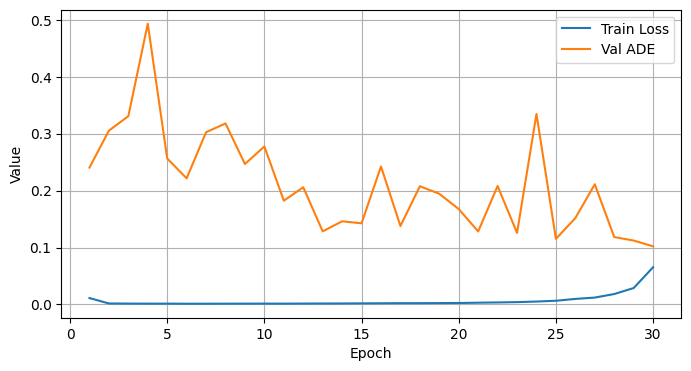

Saved deep_ver1.pt
Test ADE: 103.28226416360906
Norm ADE: 0.21798961350530302
Done


In [3]:
# ─── 0) 환경 준비 ───────────────────────────────────────────────────────────
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler

# ─── 5) TrajDataset 정의 ─────────────────────────────────────────────────────
class TrajDataset(Dataset):
    def __init__(self, df, stats):
        mean, std = stats['mean'], stats['std']
        self.samples = []
        for tid, g in df.groupby('track_id'):
            arr = g.sort_values('frame')[['center_x','center_y','angle']].values
            for i in range(len(arr) - 300 + 1):
                inp = (arr[i : i+150]         - mean) / std
                out = (arr[i+150 : i+300, :2] - mean[:2]) / std[:2]
                self.samples.append((
                    inp.astype(np.float32),
                    out.astype(np.float32)
                ))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        inp, out = self.samples[idx]
        return torch.from_numpy(inp), torch.from_numpy(out)

# ─── 6) Weighted MSE Loss 정의 ─────────────────────────────────────────────────
class WeightedMSELoss(nn.Module):
    def __init__(self, weights: torch.Tensor):
        super().__init__()
        self.register_buffer('w', weights.view(1, -1, 1))
    def forward(self, pred, target):
        diff2 = (pred - target).pow(2)
        return (diff2 * self.w).mean()

# ─── 7) Seq2Seq LSTM 모델 정의 (확장된 용량 + Dropout) ───────────────────────
class Seq2SeqLSTM(nn.Module):
    def __init__(self, in_dim=3, hid_dim=128, layers=3, out_dim=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.LSTM(in_dim, hid_dim, layers,
                               batch_first=True, dropout=dropout)
        self.decoder = nn.LSTM(out_dim, hid_dim, layers,
                               batch_first=True, dropout=dropout)
        self.fc      = nn.Linear(hid_dim, out_dim)

    def forward(self, x, target=None, teacher_forcing_ratio=0.0):
        batch_size = x.size(0)
        _, (h, c) = self.encoder(x)
        dec_in = torch.zeros(batch_size, 1, 2, device=x.device)
        outputs = []
        seq_len = target.size(1) if target is not None else 150
        for t in range(seq_len):
            dec_out, (h, c) = self.decoder(dec_in, (h, c))
            pred = self.fc(dec_out)
            outputs.append(pred)
            if target is not None and random.random() < teacher_forcing_ratio:
                dec_in = target[:, t:t+1, :]
            else:
                dec_in = pred
        return torch.cat(outputs, dim=1)

# ─── 8) 학습/검증 함수 정의 (Scheduler + Weighted Loss + Teacher Forcing) ─────
def train_model(model, tr_loader, va_loader, weights, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True
    )
    criterion = WeightedMSELoss(weights)
    scaler    = GradScaler()

    train_losses, val_ades = [], []
    for ep in range(1, epochs+1):
        tf_ratio = 1.0 - (ep-1) / (epochs-1) if epochs > 1 else 0.0
        print(f"[Epoch {ep}/{epochs}] TF ratio={tf_ratio:.2f}")

        model.train()
        total_loss = 0.0
        for x, y in tr_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            with autocast('cuda'):
                pred = model(x, y, tf_ratio)
                loss = criterion(pred, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * x.size(0)
        avg_loss = total_loss / len(tr_loader.dataset)
        train_losses.append(avg_loss)

        model.eval()
        dist_sum, cnt = 0.0, 0
        with torch.no_grad():
            for x, y in va_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                pred = model(x)
                ade = torch.norm(pred - y, dim=2).mean().item()
                dist_sum += ade * x.size(0)
                cnt += x.size(0)
        avg_ade = dist_sum / cnt
        val_ades.append(avg_ade)

        print(f"    Loss: {avg_loss:.4f} | Val ADE: {avg_ade:.4f}")
        scheduler.step(avg_ade)

    return model, train_losses, val_ades

# ─── main 진입점 및 실행 ─────────────────────────────────────────────────────
if __name__ == '__main__':
    from multiprocessing import freeze_support
    freeze_support()

    # 환경 설정
    SEED=42; random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=True
    DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {DEVICE}")

    BASE_DIR=Path('.'); os.chdir(BASE_DIR)
    print("Files:", os.listdir())

    train_df=pd.read_csv('train.csv'); val_df=pd.read_csv('validation.csv')
    test_df=pd.read_csv('test.csv'); fmt_df=pd.read_csv('submission_format.csv')
    coords=train_df[['center_x','center_y','angle']].values
    stats={'mean':coords.mean(0),'std':coords.std(0)}

    train_ld=DataLoader(TrajDataset(train_df,stats),batch_size=64,shuffle=True,
                        num_workers=8,pin_memory=True)
    val_ld  =DataLoader(TrajDataset(val_df,stats),batch_size=64,shuffle=False,
                        num_workers=8,pin_memory=True)

    model=Seq2SeqLSTM().to(DEVICE)
    try: model=torch.compile(model); print('Compiled')
    except: pass

    # 가중치 스케일 정의
    weights=torch.linspace(1.0,3.0,150,device=DEVICE)

    # 학습
    model, train_losses, val_ades = train_model(
        model, train_ld, val_ld, weights,
        epochs=30, lr=1e-3
    )

    # 시각화
    epochs=len(train_losses)
    plt.figure(figsize=(8,4))
    plt.plot(range(1,epochs+1),train_losses,label='Train Loss')
    plt.plot(range(1,epochs+1), val_ades,label='Val ADE')
    plt.xlabel('Epoch'); plt.ylabel('Value'); plt.legend(); plt.grid(True); plt.show()

    torch.save(model.state_dict(),'deep_ver1.pt'); print('Saved deep_ver1.pt')

    # 예측 및 평가
    model.eval()
    inv_mean,inv_std=stats['mean'][:2],stats['std'][:2]
    preds,gts=[],[]
    for tid in fmt_df.track_id.unique():
        traj=test_df[test_df.track_id==tid].sort_values('frame')
        inp=traj[['center_x','center_y','angle']].values[:150]
        inp_n=(inp-stats['mean'])/stats['std']
        x=torch.from_numpy(inp_n.astype(np.float32)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            _,(h,c)=model.encoder(x)
            dec_in=torch.zeros(1,1,2,device=DEVICE); block=[]
            for _ in range(len(fmt_df[fmt_df.track_id==tid])):
                dec_out,(h,c)=model.decoder(dec_in,(h,c)); pred_n=model.fc(dec_out)
                block.append(pred_n); dec_in=pred_n
            block_n=torch.cat(block,1)[0].cpu().numpy()
        preds.append(block_n*inv_std+inv_mean)
        gt=traj[['center_x','center_y']].values[150:150+block_n.shape[0]]; gts.append(gt)
    preds_arr=np.vstack(preds); gts_arr=np.vstack(gts)
    fmt_df[['pred_center_x','pred_center_y']]=preds_arr; fmt_df.to_csv('submission.csv',index=False)
    d=np.linalg.norm(preds_arr-gts_arr,axis=1);
    print('Test ADE:',d.mean()); n=np.linalg.norm((preds_arr-inv_mean)/inv_std-(gts_arr-inv_mean)/inv_std,axis=1).mean();
    print('Norm ADE:',n); print('Done')
